In [36]:
import pandas as pd
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, classification_report
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
import seaborn as sns

data = {}

def load_json(file_path):
    with open(file_path, 'r', encoding="utf-8") as file:
        return json.load(file)


def preprocess_token_data(data: dict) -> pd.DataFrame:
    records = []
    for mint, token in data.items():
        for price_change in token.get("marketCapHistory", []):
            timestamp = price_change.get("timestamp")
            if timestamp > 10*10:
                timestamp = timestamp/1000
            records.append({
                "timestamp": timestamp,
                "marketCap": price_change.get("marketCap", 0),
                "symbol": token.get("symbol", "Unknown"),
                "volume": token.get("volume", 0),
                "numHolders": token.get("numHolders", 0),
                "sniperCount": token.get("sniperCount", 0),
                "progress": token.get("progress", 0),
                "buySellRatio": token.get("buySellRatio", 0),
                "liquidity": token.get("liquidity", 0),
                "volatility": token.get("volatility", 0)
            })

        for neo in token.get("Neo", []):
            records.append({
                "symbol": token.get("symbol", "Unknown"),
                "holderCounts": neo.get("holderCounts", 0),
                "tagsCount": neo.get("tagsCount", 0),
                "devHoldingSupplyPerc": neo.get("devHoldingSupplyPerc", 0),
                "insiderWalletsSupplyPerc": neo.get("insiderWalletsSupplyPerc", 0)
            })

        for trades in token.get("trades", []):
            records.append({
                "timestamp": trades.get("timestamp"),
                "symbol": token.get("symbol", "Unknown"),
                "solAmount": trades.get("solAmount", 0),
                "isBuy": trades.get("isBuy", 0),
            })

    return pd.DataFrame(records)


files = [
    'data/coiny_bez_limitu6.json',
    'data/coiny_bez_limitu7.json',
    'data/coiny_bez_limitu8.json',
    'data/coiny_bez_limitu9.json',
    'data/coiny_bez_limitu10.json',
    'data/coiny_bez_limitu11.json',
]

for file in files:
    data.update(load_json(file))

df = preprocess_token_data(data)
df

,timestamp,marketCap,symbol,volume,numHolders,sniperCount,progress,buySellRatio,liquidity,volatility,holderCounts,tagsCount,devHoldingSupplyPerc,insiderWalletsSupplyPerc,solAmount,isBuy
0,1.738860e+06,7887.522187,СОСКY,15.4587,21.0,10.0,24.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1.738860e+06,7892.808009,СОСКY,15.4587,21.0,10.0,24.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1.738860e+09,7885.040000,СОСКY,15.4587,21.0,10.0,24.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1.738860e+06,7935.138594,СОСКY,15.4587,21.0,10.0,24.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1.738860e+06,7973.608513,СОСКY,15.4587,21.0,10.0,24.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409964,1.739034e+09,NaN,OFI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000e+09,True
409965,1.739034e+06,5432.958982,LCSE,0.0000,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
409966,1.739034e+09,NaN,LCSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.005390e+07,True
409967,1.739034e+06,5476.591540,ice,0.0000,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.sort_values(['symbol', 'timestamp'], inplace=True)

df['marketCap_change'] = df.groupby('symbol')['marketCap'].pct_change().fillna(0)
df['marketCap_ema'] = df.groupby('symbol')['marketCap'].transform(lambda x: x.ewm(span=7).mean())
df['rsi'] = df.groupby('symbol')['marketCap'].transform(lambda x:
    100 - (100 / (1 + x.pct_change().fillna(0).rolling(window=7).mean() / x.pct_change().fillna(0).rolling(window=7).std())))

df['marketCap_change_ratio'] = (df['marketCap'] - df['marketCap'].shift(1)) / df['marketCap'].shift(1)
df['holders_growth'] = df['numHolders'].diff().fillna(0)
df['volatility_to_volume_ratio'] = df['volatility'] / (df['volume'] + 1)

## Normalization
scaler = StandardScaler()
features_to_scale = ['marketCap', 'volume', 'numHolders', 'volatility']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df

,timestamp,marketCap,symbol,volume,numHolders,sniperCount,progress,buySellRatio,liquidity,volatility,...,devHoldingSupplyPerc,insiderWalletsSupplyPerc,solAmount,isBuy,marketCap_change,marketCap_ema,rsi,marketCap_change_ratio,holders_growth,volatility_to_volume_ratio
120353,1970-01-01 00:00:00.001738867,-0.684289,,-0.386521,-0.468673,2.0,8.19,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,5922.552091,NaN,NaN,0.0,0.0
120354,1970-01-01 00:00:00.001738867,-0.684289,,-0.386521,-0.468673,2.0,8.19,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,5922.552091,NaN,0.000000,0.0,0.0
120356,1970-01-01 00:00:00.001738867,-0.696512,,-0.386521,-0.468673,2.0,8.19,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,-0.028486,5849.596030,NaN,-0.028486,0.0,0.0
120357,1970-01-01 00:00:00.001738867,-0.696512,,-0.386521,-0.468673,2.0,8.19,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,5814.577120,NaN,0.000000,0.0,0.0
120358,1970-01-01 00:00:00.001738867,-0.696512,,-0.386521,-0.468673,2.0,8.19,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,5794.668803,NaN,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124134,1970-01-01 00:00:01.738868202,NaN,🪦,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,20000000.0,True,0.000000,5560.532010,NaN,NaN,0.0,NaN
124135,1970-01-01 00:00:01.738868202,NaN,🪦,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,225143630.0,False,0.000000,5560.532010,NaN,NaN,0.0,NaN
124130,1970-01-01 00:00:01.738868203,-0.727690,🪦,-0.348167,-0.486215,7.0,0.09,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,5329.815208,NaN,NaN,0.0,0.0
123649,NaT,NaN,🪦,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.1095,0.0,NaN,NaN,0.000000,5329.815208,NaN,NaN,0.0,NaN


In [38]:
df.isnull().sum().sum()

np.int64(4451336)

# Labelovací Funkce pro Investiční Příležitosti

## Jak Funguje
Funkce `label_investment` přiřazuje labely investičním příležitostem na základě růstu tržní kapitalizace během různých časových oken (7, 15 a 30).

## Logika Labelování
- **Label 1 (Nákupní signál)**: Pokud coin vzroste o více než **50%** v jakémkoliv z časových oken (7, 15, nebo 30)
- **Label 0**: Pokud nedojde k dostatečnému růstu

## Důležité
Tato strategie identifikuje **early-stage příležitosti** - coiny, které mají potenciál rychlého růstu krátce po jejich objevení.

## Distribuce Tříd
Jak vidíte níže, data jsou velmi **nebalancovaná** - většina coinů nedosáhne 50% růstu. Proto budeme později používat SMOTE pro vyvážení trénovací sady.

In [39]:
def label_investment(group) -> pd.Series:
    time_windows = [7, 15, 30]

    labels = pd.Series(0, index=group.index)

    if len(group) < min(time_windows):
        return labels

    initial_market_cap = group['marketCap'].iloc[0]

    for window in time_windows:
        if len(group) >= window:
            max_growth = (group['marketCap'].iloc[:window].max() - initial_market_cap) / (initial_market_cap + 1e-6)
            if max_growth > 0.50:
                labels[:] = 1
                break

    return labels


df['label'] = df.groupby('symbol', group_keys=False).apply(label_investment)

# Fillna pouze pro numericke sloupce (ne pro datetime)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

features = ['marketCap_change', 'marketCap_ema', 'rsi', 'marketCap_change_ratio', 'holders_growth', 'volatility_to_volume_ratio']
X = df[features]
y = df['label']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

joblib.dump(features, 'features.joblib')

df['label'].value_counts()

label
0    381399
1     28570
Name: count, dtype: int64

# PYTORCH KONFIGURACE

In [40]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, confusion_matrix

# Hyperparametry
CONFIG = {
    "hidden_layers": [512, 256, 128, 64],
    "dropout_rate": 0.3,
    "learning_rate": 0.001,
    "batch_size": 256,
    "epochs": 30,
    "n_splits": 5,  # TimeSeriesSplit folds
    "smote_ratio": 0.5,
}

# GPU/CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pouzivam: {DEVICE}")

# Priprava dat jako numpy arrays
X_np = X.values
y_np = y.values

print(f"Celkem vzorku: {len(X_np)}")
print(f"Features: {features}")

Pouzivam: cuda
Celkem vzorku: 409969
Features: ['marketCap_change', 'marketCap_ema', 'rsi', 'marketCap_change_ratio', 'holders_growth', 'volatility_to_volume_ratio']


# PyTorch Dataset a Model

## Custom Dataset
PyTorch Dataset musí implementovat `__len__` a `__getitem__`.

## Neuronová síť
Feedforward síť s:
- Skryté vrstvy: 128 → 64 → 32
- Aktivace: ReLU
- Regularizace: Dropout + BatchNorm
- Výstup: Sigmoid (binární klasifikace)

In [41]:
class CryptoDataset(Dataset):
    """Custom Dataset pro krypto data."""
    
    def __init__(self, features: np.ndarray, labels: np.ndarray):
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# NEURONOVA SIT
class BuyPredictionModel(nn.Module):
    """Feedforward sit pro binarni klasifikaci."""
    
    def __init__(self, input_size: int, hidden_layers: list, dropout_rate: float = 0.3):
        super(BuyPredictionModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_layers:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.BatchNorm1d(hidden_size),
            ])
            prev_size = hidden_size
        
        # Vystupni vrstva
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# Test modelu
input_size = len(features)
model = BuyPredictionModel(input_size, CONFIG["hidden_layers"], CONFIG["dropout_rate"])
print(f"Model architektura:\n{model}")
print(f"\nCelkem parametru: {sum(p.numel() for p in model.parameters()):,}")

Model architektura:
BuyPredictionModel(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (16): Linear(in_features=64, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Celkem parametru: 

In [42]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Trenovani jedne epochy."""
    model.train()
    total_loss = 0.0
    
    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion, device):
    """Evaluace modelu."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    
    return total_loss / len(test_loader), np.array(all_preds), np.array(all_labels)


def train_fold(X_train, y_train, X_test, y_test, config, device, fold_num):
    """Trenink jednoho foldu s SMOTE."""
    
    # 1. SMOTE pouze na trenovaci data
    smote = SMOTE(sampling_strategy=config["smote_ratio"], random_state=42, k_neighbors=3)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"  Po SMOTE: {len(X_train_resampled)} vzorku (puvodni: {len(X_train)})")
    
    # 2. Vytvoreni DataLoaderu
    train_dataset = CryptoDataset(X_train_resampled, y_train_resampled)
    test_dataset = CryptoDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)
    
    # 3. Model, loss, optimizer
    model = BuyPredictionModel(
        input_size=X_train.shape[1],
        hidden_layers=config["hidden_layers"],
        dropout_rate=config["dropout_rate"]
    ).to(device)
    
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    
    # 4. Trenovaci smycka
    best_auc = 0
    for epoch in range(config["epochs"]):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, preds, labels = evaluate(model, test_loader, criterion, device)
        
        auc = roc_auc_score(labels, preds)
        if auc > best_auc:
            best_auc = auc
        
        if (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, AUC={auc:.4f}")
    
    # 5. Finalni evaluace
    _, final_preds, final_labels = evaluate(model, test_loader, criterion, device)
    final_auc = roc_auc_score(final_labels, final_preds)
    
    return model, final_auc, final_preds, final_labels

# Hlavní trénovací smyčka

In [43]:
print("TRENING S TIMESERIESSPLIT")


# TimeSeriesSplit - chronologicke rozdeleni
tscv = TimeSeriesSplit(n_splits=CONFIG["n_splits"])

fold_results = []
all_models = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_np)):
    print(f"FOLD {fold + 1}/{CONFIG['n_splits']}")
    print(f"  Train: index {train_idx[0]:,} - {train_idx[-1]:,} ({len(train_idx):,} vzorku)")
    print(f"  Test:  index {test_idx[0]:,} - {test_idx[-1]:,} ({len(test_idx):,} vzorku)")
    
    # Rozdeleni dat
    X_train, X_test = X_np[train_idx], X_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]
    
    print(f"  Train labels: 0={sum(y_train==0):,}, 1={sum(y_train==1):,}")
    print(f"  Test labels:  0={sum(y_test==0):,}, 1={sum(y_test==1):,}")
    
    # Trenink foldu
    model, auc, preds, labels = train_fold(X_train, y_train, X_test, y_test, CONFIG, DEVICE, fold)
    
    fold_results.append({
        'fold': fold + 1,
        'auc': auc,
        'train_size': len(train_idx),
        'test_size': len(test_idx)
    })
    all_models.append(model)
    
    print(f"\n  >> Fold {fold + 1} AUC: {auc:.4f}")

# Souhrn
print("SOUHRN VYSLEDKU")
for result in fold_results:
    print(f"Fold {result['fold']}: AUC = {result['auc']:.4f}")

avg_auc = np.mean([r['auc'] for r in fold_results])
std_auc = np.std([r['auc'] for r in fold_results])
print(f"\nPrumerne AUC: {avg_auc:.4f} (+/- {std_auc:.4f})")

TRENING S TIMESERIESSPLIT
FOLD 1/5
  Train: index 0 - 68,328 (68,329 vzorku)
  Test:  index 68,329 - 136,656 (68,328 vzorku)
  Train labels: 0=65,701, 1=2,628
  Test labels:  0=65,114, 1=3,214
  Po SMOTE: 98551 vzorku (puvodni: 68329)
    Epoch 10: Train Loss=0.6480, Test Loss=0.7876, AUC=0.3216
    Epoch 20: Train Loss=0.6499, Test Loss=0.6403, AUC=0.4024
    Epoch 30: Train Loss=0.6493, Test Loss=0.5835, AUC=0.3670

  >> Fold 1 AUC: 0.3670
FOLD 2/5
  Train: index 0 - 136,656 (136,657 vzorku)
  Test:  index 136,657 - 204,984 (68,328 vzorku)
  Train labels: 0=130,815, 1=5,842
  Test labels:  0=61,519, 1=6,809
  Po SMOTE: 196222 vzorku (puvodni: 136657)
    Epoch 10: Train Loss=0.5659, Test Loss=1.5817, AUC=0.6537
    Epoch 20: Train Loss=0.6107, Test Loss=1.4360, AUC=0.4815
    Epoch 30: Train Loss=0.5964, Test Loss=1.8294, AUC=0.5981

  >> Fold 2 AUC: 0.5981
FOLD 3/5
  Train: index 0 - 204,984 (204,985 vzorku)
  Test:  index 204,985 - 273,312 (68,328 vzorku)
  Train labels: 0=192,334,

# Vizualizace Výsledků

Graf ukazuje AUC skóre pro každý fold. TimeSeriesSplit zajišťuje, že:
- Vždy trénujeme na **starších** datech
- Vždy testujeme na **novějších** datech
- Žádný data leakage

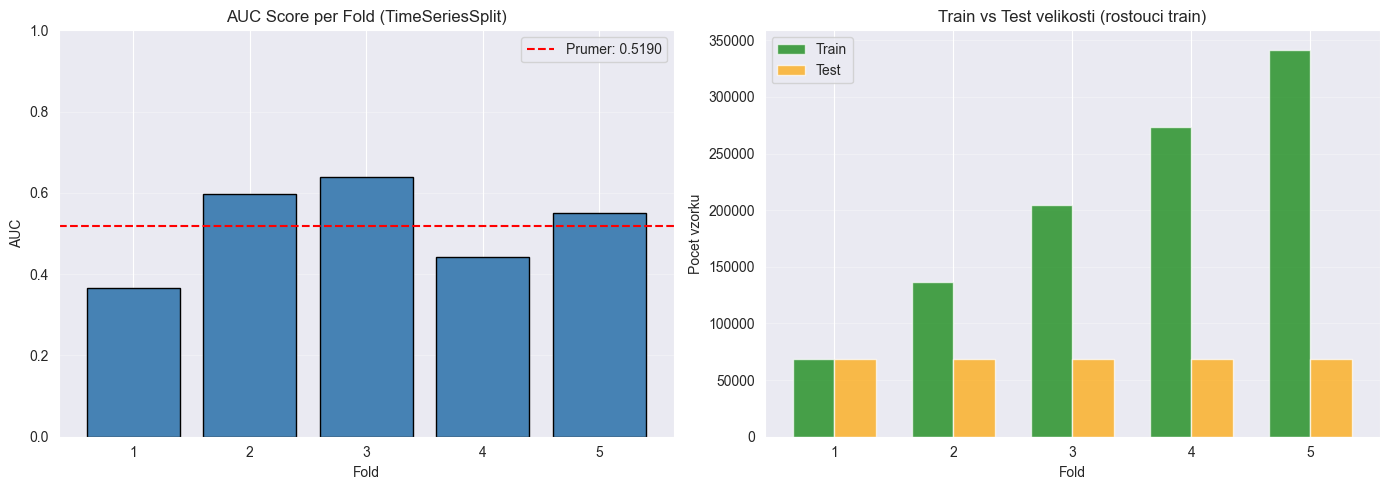


Graf ulozen: timeseries_split_results.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. AUC per fold
folds = [r['fold'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]

axes[0].bar(folds, aucs, color='steelblue', edgecolor='black')
axes[0].axhline(y=avg_auc, color='red', linestyle='--', label=f'Prumer: {avg_auc:.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC Score per Fold (TimeSeriesSplit)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Train/Test velikosti
train_sizes = [r['train_size'] for r in fold_results]
test_sizes = [r['test_size'] for r in fold_results]

x = np.arange(len(folds))
width = 0.35

axes[1].bar(x - width/2, train_sizes, width, label='Train', color='green', alpha=0.7)
axes[1].bar(x + width/2, test_sizes, width, label='Test', color='orange', alpha=0.7)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Pocet vzorku')
axes[1].set_title('Train vs Test velikosti (rostouci train)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(folds)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_split_results.png', dpi=150)
plt.show()

print("\nGraf ulozen: timeseries_split_results.png")

In [49]:
# Vyber nejlepsi model podle AUC
best_fold_idx = np.argmax([r['auc'] for r in fold_results])
best_model = all_models[best_fold_idx]
best_auc = fold_results[best_fold_idx]['auc']

print(f"Nejlepsi model: Fold {best_fold_idx + 1} (AUC: {best_auc:.4f})")

# Ulozeni modelu
torch.save({
    'model_state_dict': best_model.state_dict(),
    'config': CONFIG,
    'features': features,
    'input_size': len(features),
    'best_auc': best_auc,
    'fold_results': fold_results,
}, 'buy_model_pytorch.pth')

print("Model ulozen: buy_model_pytorch.pth")

# Classification report pro posledni fold
print("CLASSIFICATION REPORT (posledni fold)")

# Pouzijeme posledni fold pro finalni report
last_model = all_models[-1]
last_model.eval()

# Vytvorime test loader pro posledni fold
last_train_idx, last_test_idx = list(tscv.split(X_np))[-1]
X_test_last = X_np[last_test_idx]
y_test_last = y_np[last_test_idx]

test_dataset = CryptoDataset(X_test_last, y_test_last)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

_, final_preds, final_labels = evaluate(last_model, test_loader, nn.BCELoss(), DEVICE)

# Binarni predikce
predicted_classes = (final_preds > 0.5).astype(int)

print(classification_report(final_labels.astype(int), predicted_classes, target_names=['No Buy', 'Buy']))

Nejlepsi model: Fold 3 (AUC: 0.6380)
Model ulozen: buy_model_pytorch.pth
CLASSIFICATION REPORT (posledni fold)
              precision    recall  f1-score   support

      No Buy       0.86      0.00      0.00     61692
         Buy       0.10      1.00      0.18      6636

    accuracy                           0.10     68328
   macro avg       0.48      0.50      0.09     68328
weighted avg       0.78      0.10      0.02     68328



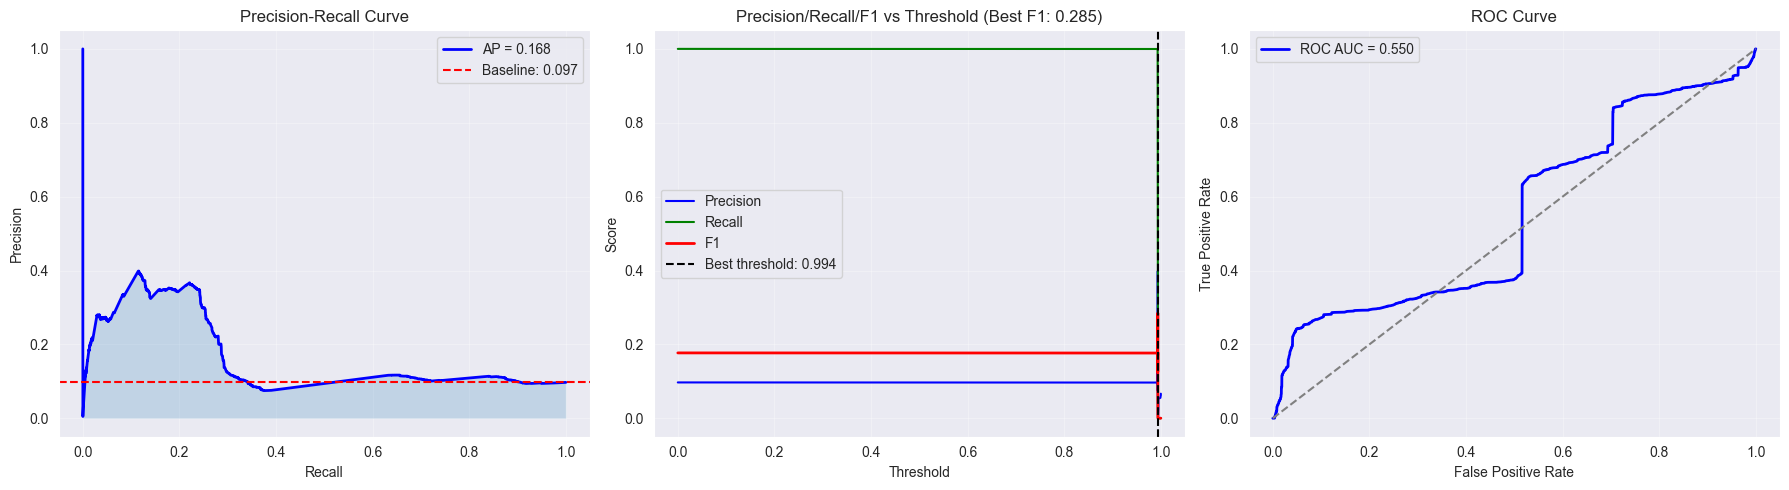


Nejlepsi threshold podle F1: 0.9936
Nejlepsi F1 score: 0.2851
Average Precision (AP): 0.1679


In [50]:
# PRECISION-RECALL CURVE

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(final_labels, final_preds)
avg_precision = average_precision_score(final_labels, final_preds)

axes[0].plot(recall, precision, color='blue', lw=2, label=f'AP = {avg_precision:.3f}')
axes[0].fill_between(recall, precision, alpha=0.2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Baseline (random classifier)
baseline = sum(final_labels) / len(final_labels)
axes[0].axhline(y=baseline, color='red', linestyle='--', label=f'Baseline: {baseline:.3f}')
axes[0].legend()

# 2. F1 Score vs Threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

axes[1].plot(thresholds_pr, precision[:-1], label='Precision', color='blue')
axes[1].plot(thresholds_pr, recall[:-1], label='Recall', color='green')
axes[1].plot(thresholds_pr, f1_scores, label='F1', color='red', lw=2)
axes[1].axvline(x=best_threshold, color='black', linestyle='--', label=f'Best threshold: {best_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title(f'Precision/Recall/F1 vs Threshold (Best F1: {best_f1:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. ROC Curve pro porovnani
fpr, tpr, _ = roc_curve(final_labels, final_preds)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='blue', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curve_analysis.png', dpi=150)
plt.show()

print(f"\nNejlepsi threshold podle F1: {best_threshold:.4f}")
print(f"Nejlepsi F1 score: {best_f1:.4f}")
print(f"Average Precision (AP): {avg_precision:.4f}")

CLASSIFICATION REPORT (threshold = 0.9936)
              precision    recall  f1-score   support

      No Buy       0.92      0.95      0.94     61692
         Buy       0.35      0.24      0.29      6636

    accuracy                           0.88     68328
   macro avg       0.63      0.60      0.61     68328
weighted avg       0.87      0.88      0.87     68328

Confusion Matrix:
[[58672  3020]
 [ 5031  1605]]


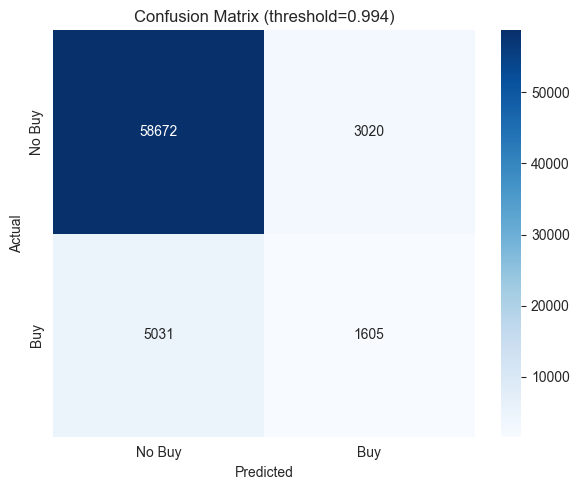

In [51]:
print(f"CLASSIFICATION REPORT (threshold = {best_threshold:.4f})")

# Aplikuj optimalni threshold
predicted_optimal = (final_preds > best_threshold).astype(int)

print(classification_report(
    final_labels.astype(int), 
    predicted_optimal, 
    target_names=['No Buy', 'Buy']
))

# Confusion matrix
cm = confusion_matrix(final_labels.astype(int), predicted_optimal)
print("Confusion Matrix:")
print(cm)

# Vizualizace confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Buy', 'Buy'], 
            yticklabels=['No Buy', 'Buy'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={best_threshold:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix_optimal.png', dpi=150)
plt.show()